# Imports

In [1]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import cv2
from scipy.signal import convolve2d
from scipy.fft import ifft2

# Methods

In [4]:
def apply_fourier_transform(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = np.log(np.abs(f_shift) + 1) # 20 * np.log(np.abs(f_shift) + 1)
    return magnitude_spectrum, f_shift


In [5]:
def box_blur_manual(img, ksize=(3, 3)):
    # Tamanho do kernel
    k_h, k_w = ksize
    pad_h = k_h // 2
    pad_w = k_w // 2

    # Cria uma cópia da imagem com padding (borda replicada)
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')

    # Cria a imagem de saída
    output = np.zeros_like(img, dtype=np.uint8)

    # Aplica o filtro manualmente
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i + k_h, j:j + k_w]
            mean_val = np.mean(region)
            output[i, j] = int(mean_val)

    return output

# Parameters

In [6]:
path_assets = PROJECT_DIR / 'assets'
path_imgs_atv = path_assets / "atv02_lista02-assets"

# Questão 09

In [7]:
img_names = ["cameraman.png", "cameraman_pattern.png"]
# img = cv2.imread(path_assets / "atv02_lista02-assets" / 'cameraman_pattern.png', cv2.IMREAD_GRAYSCALE)
imgs = {
    i.split(".")[0]: cv2.imread(path_imgs_atv / i, cv2.IMREAD_GRAYSCALE) for i in img_names
}

# imgs["cameraman_pattern_cut"] = imgs["cameraman_pattern"][0:150, 0:200]

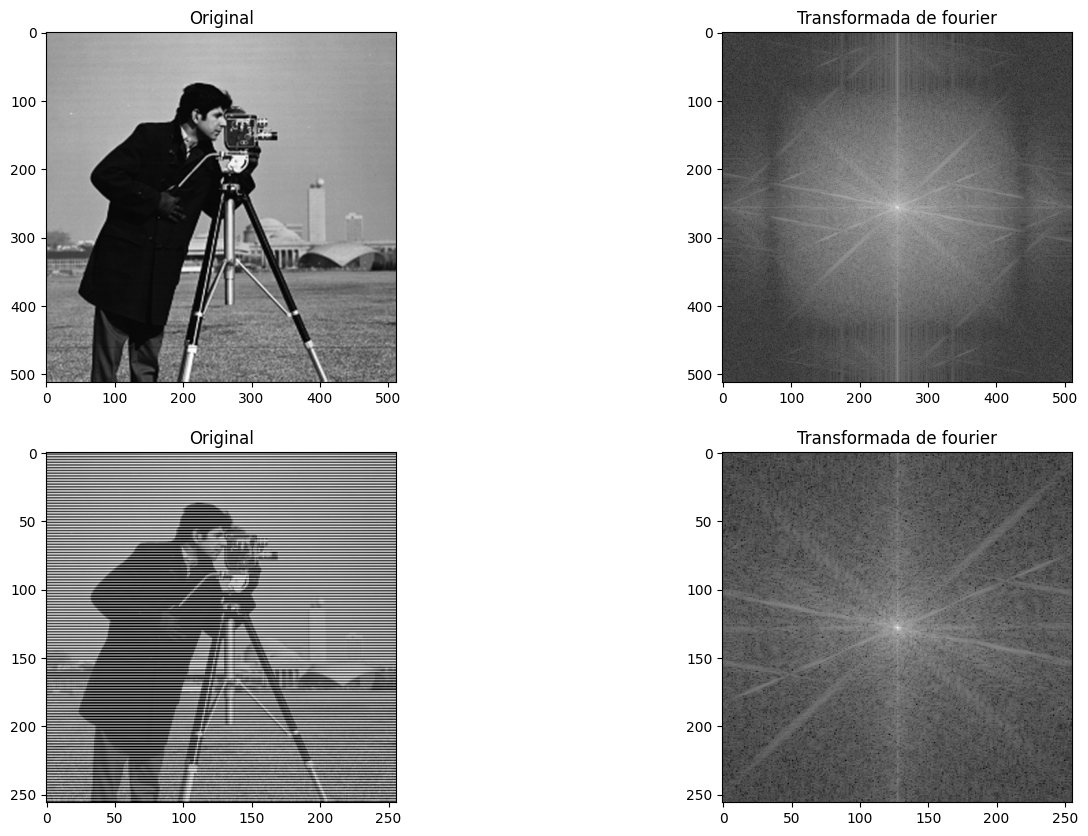

In [8]:
fourier = {
    name: {
        "tft": apply_fourier_transform(img)[1],
        "spectrum": apply_fourier_transform(img)[0]
    } for name, img in imgs.items()
}
# Mostrar imagem resultante
fig, ax = plt.subplots(len(fourier), 2, figsize=(16, 10))
for _ax, name in zip(ax, fourier.keys()):
    _ax[0].imshow(imgs[name], cmap='gray')
    _ax[0].set_title('Original')
    _ax[1].imshow(fourier[name]["spectrum"].astype(float), cmap='gray')
    _ax[1].set_title('Transformada de fourier')
    #_ax[0].axis('off')
    #_ax[1].axis('off')
fig.savefig(path_assets / "atv02-q09-init.png", bbox_inches='tight', dpi=400)
plt.show()


## a) uma solução aplicada no domínio da frequência

Vamos aplicar um filtro passa-baixa gaussiano para a solução aplicada no domínio da frequências. Sera aplicado um range de &sigma; para avaliação de qual recupera melhor a imagem sem as linhas verticais e consegue conservar melhor o nivel de detalhes.

In [9]:
img = imgs["cameraman_pattern"]

# Aplicar a Transformada de Fourier
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

# Adaptação do que foi visto em aula, para python:
# Ref.: Slide 06 - Filtragem - Pagina 50
nx = dft.shape[1]
ny = dft.shape[0]
cxrange = np.concatenate(
    (
        np.arange(0, nx // 2 + 1),
        np.arange(-nx // 2 + 1, 0)
    )
)
cyrange = np.concatenate(
    (
        np.arange(0, ny // 2 + 1),
        np.arange(-ny // 2 + 1, 0)
    )
)
cx, cy = np.meshgrid(cxrange, cyrange)
fxrange = cxrange * 2 * np.pi / nx
fyrange = cyrange * 2 * np.pi / ny
fx, fy = np.meshgrid(fxrange, fyrange)

# Lista de sigmas a serem testados
sigmas = [0.3, 0.5, 0.7, 0.9, 1, 1.5, 3]

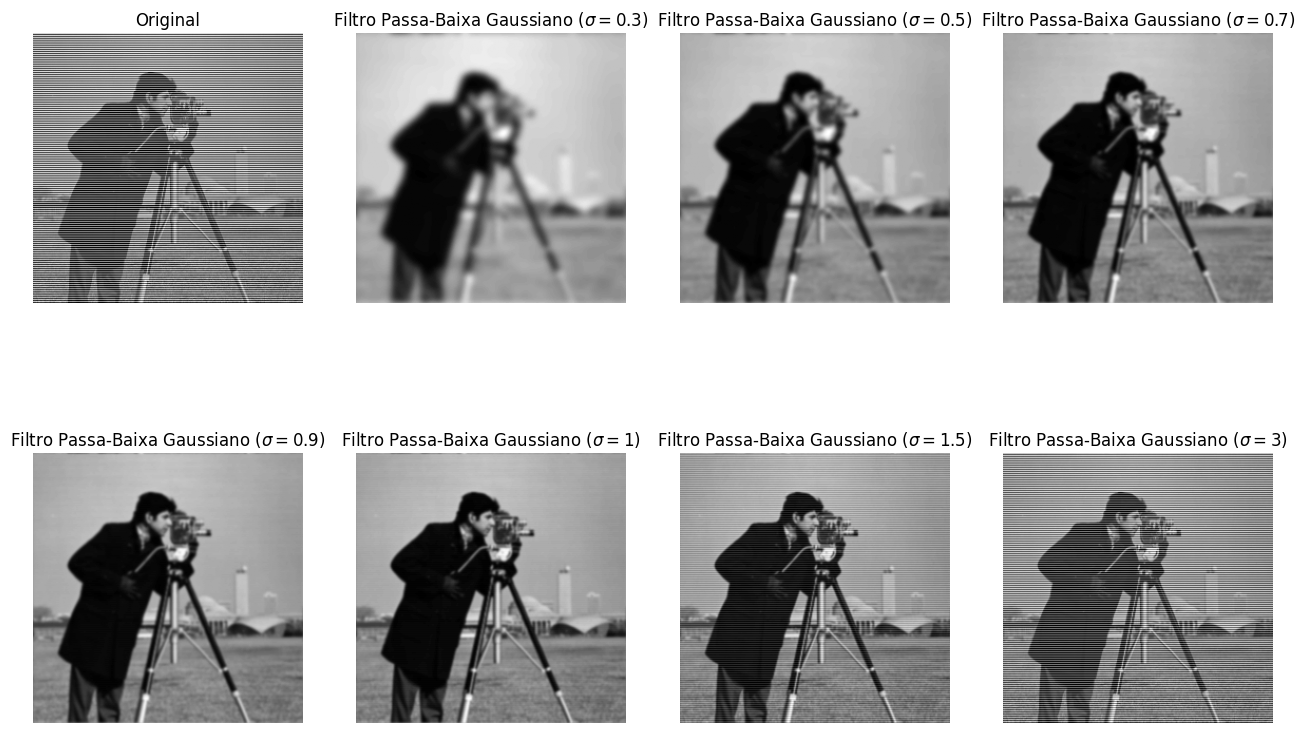

In [10]:
fig, ax = plt.subplots(2, (len(sigmas) // 2) + 1, figsize=(16, 10))
ax = ax.flatten()
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original')
for _ax in ax:
    _ax.axis('off')
for idx, sigma in enumerate(sigmas):
    # Filtro passa baixa gaussiano
    ms = np.exp(-(fx**2 + fy**2) / (2 * (sigma**2)))

    # Aplicar o filtro
    smoothF = dft * ms
    smooth = np.abs(ifft2(smoothF))

    # Exibir a imagem suavizada
    ax[idx + 1].imshow(smooth.round().astype(int), cmap='gray')
    ax[idx + 1].set_title("Filtro Passa-Baixa Gaussiano " + rf"($\sigma={sigma}$)")
    ax[idx + 1].axis('off')
fig.savefig(path_assets / "atv02-q09-a1.png", bbox_inches='tight', dpi=400)
plt.show()

### Conclusão


Analisando detalhadamente, podemos notar que os filtros considerando &sigma; = 3 e &sigma; = 0.3 podem ser descartados, uma vez que um apresentou ainda a presença do tracejado horizontal na imagem, enquanto o outro  apresenta um grau de borramento maior, quase sendo imperceptivel detectar detalhes do fundo da imagem, respectivamente.

Considerando o &sigma; = 1.5, a imagem mantem um nivel de detalhes consideravel, contudo, ainda que leve, a imagem ainda apresenta linhas tracejadas no fundo, algumas sendo bem evidentes. Os valores de &sigma; = {0.5, 0.7, 0.9} apresentaram um pouco mais de detalhes, mas um nivel de borramento ainda elevado.

Por fim, o &sigma; ideal para esse problema pode ser considerado 1, uma vez que ele conseguiu conservar detalhes da imagem, desparecendo com as linhas horizontais e ainda apresentando um nível de borramento mínimo.

## b) uma solução aplicada no domínio espacial

In [11]:
## metodo usando filtro linear

# mascaras utilizadas
hs = {
    "Filtro 01": np.array(
        [
            [0, 0, 0],
            [0, 1, 1],
            [0, 1, 1]
        ]
    ),
    "Filtro 02": np.array(
        [
            [0, 1, 0],
            [1, 0, 1],
            [0, 1, 0]
        ]
    ),
    "Filtro 03": np.array(
        [
            [1, 1, 1],
            [1, 0, 1],
            [1, 1, 1]
        ]
    ),
    "Filtro 04": np.array(
        [
            [1, 0, 1],
            [0, 0, 0],
            [1, 0, 1]
        ]
    ),
}

for key, h in hs.items():
    # Normaliza a máscara
    h = h / np.sum(h)

# aplicação da correlação cruzada
filtered_img = {
    key: convolve2d(
        imgs["cameraman_pattern"],
        h,
        mode='same',
        boundary='fill',
        fillvalue=0
    ).round().astype(int) for key, h in hs.items()
}

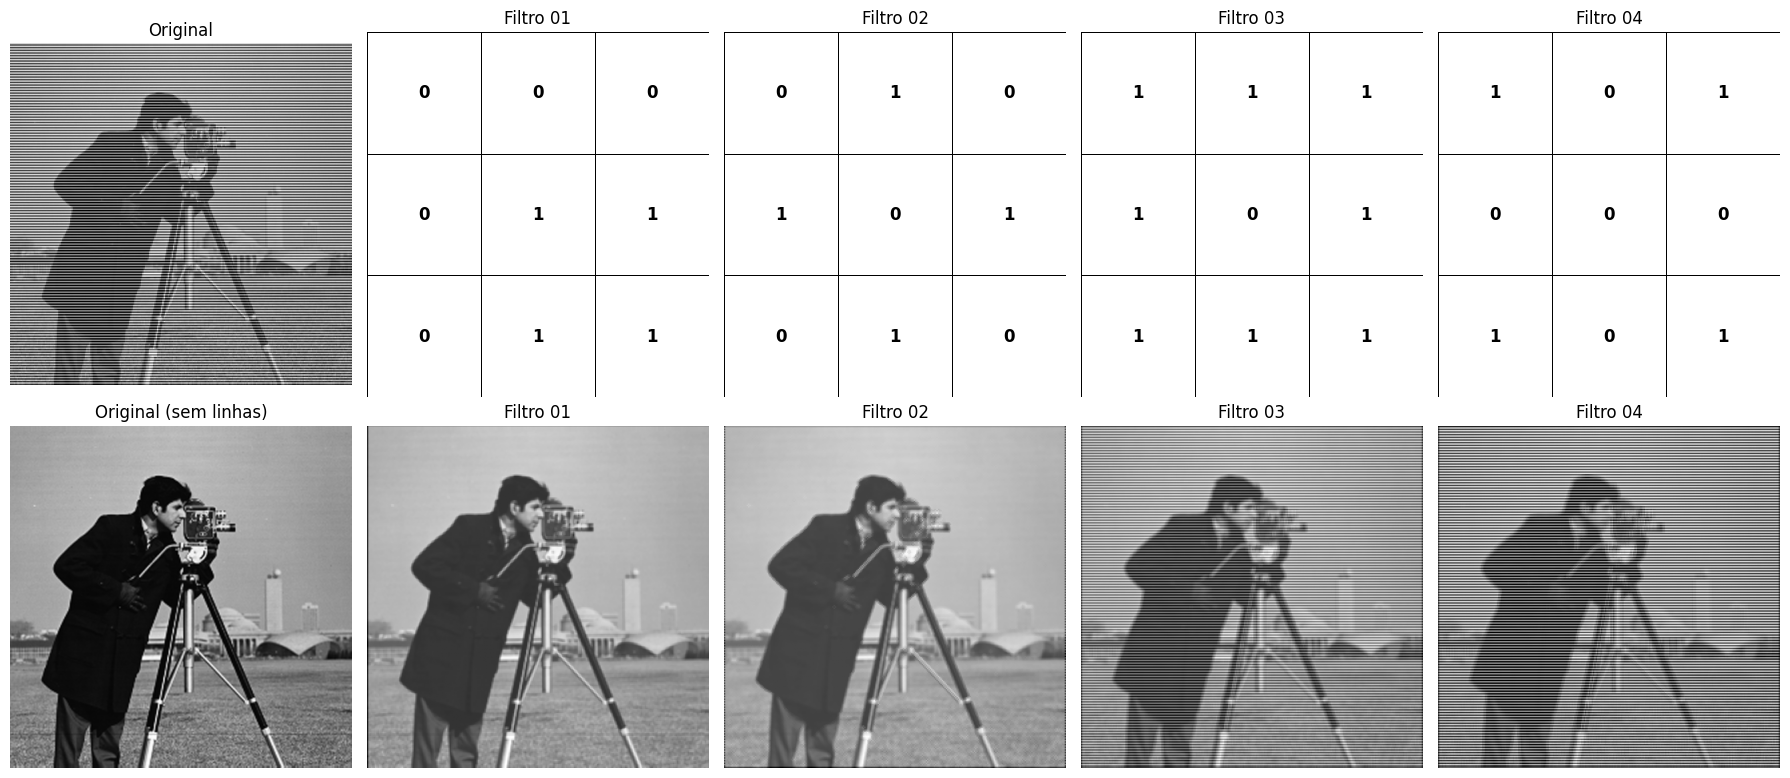

In [12]:
fig, ax = plt.subplots(2, len(filtered_img.keys()) + 1, figsize=(18, 8))

ax[0, 0].set_title('Original')
ax[0, 0].imshow(imgs["cameraman_pattern"], cmap='gray')
ax[0, 0].axis('off')

ax[1, 0].set_title('Original (sem linhas)')
ax[1, 0].imshow(imgs["cameraman"], cmap='gray')
ax[1, 0].axis('off')

# Exibir as máscaras e as imagens filtradas
for _ax, (title, content) in zip(ax.T[1:], filtered_img.items()):
    # Normalizar a máscara para  [0, 1]
    mask = hs[title]
    mask_normalized = (mask - mask.min()) / (mask.max() - mask.min())

    # _ax[0].imshow(mask_normalized, cmap='gray')
    sns.heatmap(
        mask_normalized,
        ax=_ax[0],
        cbar=False,
        annot=True,
        fmt=".0f",
        annot_kws={"color": "black", "fontsize": 12, "weight": "bold"}, 
        linewidths=0.5,
        linecolor='black',
        cmap='binary',
        vmin=1, vmax=1
    )
    _ax[0].set_title(title)
    _ax[0].axis('off')

    _ax[1].imshow(content, cmap='gray')
    _ax[1].set_title(f"{title}")
    _ax[1].axis('off')

fig.tight_layout()
fig.savefig(path_assets / "atv02-q09-b2.png", dpi=400, bbox_inches='tight')
plt.show()

### Conclusão
Entre os filtros testadas, o Filtro 1 apresentou os melhores resultados, conseguindo remover completamente as linhas horizontais presentes na imagem cameraman_pattern.png. Além disso, essa máscara conseguiu manter os detalhes da imagem original e apresentou o menor nível de borramento.

O filtro 2 também foi capaz de eliminar as linhas horizontais, mas apresentou um borramento mais evidente, o que comprometeu visualmente a qualidade da imagem. Por outro lado, os filtros 3 e 4 não foram eficazes. Ambas não foram eficientes em remover as linhas horizontais e ainda introduziram um efeito de borramento significativo, prejudicando a nitidez e os detalhes da imagem.

Dessa forma, temos que o **filtro 1** foi a mais adequada para resolver o problema, equilibrando a remoção do padrão de linhas com a preservação da qualidade da imagem.

* **Filtro selecionado:**

$$
h = \left(\frac{1}{4}\right) \cdot \left[\begin{matrix}
    0 & 0 & 0 \\
    0 & 1 & 1 \\
    0 & 1 & 1 \\
\end{matrix}\right]
$$